# DenseNet-121
## Mục tiêu
- Sử dụng DenseNet-121 pre-trained cho bài toán CIFAR-10.
- Thay đổi `model.classifier` thành 10 lớp.
- Áp dụng Transfer Learning và Fine-tuning.
- So sánh hai Batch Size: **32** và **64**.
- Giữ nguyên Learning Rate, Optimizer và số Epoch giữa hai thí nghiệm.
- Theo dõi Loss, Accuracy bằng TensorBoard.
- Ghi nhận Training Time, Memory Usage và Best Checkpoint.

# 1. Chuẩn bị môi trường và dữ liệu
Phần này sử dụng trực tiếp Data Pipeline và Training Engine dùng chung của nhóm.
Dữ liệu không được chia lại nhằm đảm bảo DenseNet-121 sử dụng cùng
Train/Validation/Test split với ResNet-18 và VGG-16.

In [14]:
from pathlib import Path
import sys
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim


# ============================================================
# Xác định thư mục Practice_2
# ============================================================

PROJECT_DIR = Path.cwd().resolve()

while (
    PROJECT_DIR.name != "Practice_2"
    and PROJECT_DIR.parent != PROJECT_DIR
):
    PROJECT_DIR = PROJECT_DIR.parent

if PROJECT_DIR.name != "Practice_2":
    raise FileNotFoundError("Không tìm thấy thư mục Practice_2.")

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))


# ============================================================
# Module dùng chung của nhóm
# ============================================================

from src.data import (
    CIFAR10_CLASSES,
    IMAGENET_MEAN,
    IMAGENET_STD,
    DataConfig,
    build_dataloaders,
)

from src.trainer import (
    get_device,
    train_model,
)

# ============================================================
# Module DenseNet-121 của Lam Linh
# ============================================================

from src.models.densenet121 import (
    build_densenet121,
    enable_finetuning_last_block,
    count_parameters,
)

print("Import thành công!")
print("PROJECT_DIR:", PROJECT_DIR)

Import thành công!
PROJECT_DIR: C:\Users\LAM LINH\OneDrive\Tài liệu\TQHDL\UTH-Deep-Learning-nhom2\Practice_2


## 1.1. Thiết lập Random Seed và thiết bị huấn luyện
Cố định Random Seed giúp tăng tính tái lập của thí nghiệm.
Thiết bị huấn luyện được lựa chọn tự động:
- Sử dụng GPU (CUDA) nếu khả dụng.
- Ngược lại sử dụng CPU.
Hai thí nghiệm Batch Size 32 và 64 sẽ sử dụng cùng Random Seed để đảm bảo điều kiện so sánh nhất quán.

In [17]:
# ============================================================
# THIẾT LẬP RANDOM SEED VÀ DEVICE
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Sử dụng hàm get_device() từ trainer.py của nhóm
device = get_device()

print("===== CẤU HÌNH MÔI TRƯỜNG =====")
print(f"Random Seed     : {SEED}")
print(f"PyTorch Version : {torch.__version__}")
print(f"Device          : {device}")
print(f"CUDA Available  : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")

===== CẤU HÌNH MÔI TRƯỜNG =====
Random Seed     : 42
PyTorch Version : 2.9.0+cpu
Device          : cpu
CUDA Available  : False


## 1.2. Kiểm tra DataLoader CIFAR-10 dùng chung
DenseNet-121 sử dụng trực tiếp Data Pipeline được xây dựng chung cho toàn bộ nhóm. Việc sử dụng cùng Train/Validation/Test split giúp đảm bảo các mô hình
ResNet-18, VGG-16 và DenseNet-121 được đánh giá trên cùng một tập dữ liệu.
Ở bước này, sử dụng Batch Size = 32 để kiểm tra:
- Số lượng mẫu Train, Validation và Test.
- Số lớp của CIFAR-10.
- Kích thước một batch ảnh trước khi đưa vào DenseNet-121.

In [18]:
# ============================================================
# KIỂM TRA DATALOADER CIFAR-10 DÙNG CHUNG
# ============================================================

data_config = DataConfig(
    data_dir=PROJECT_DIR / "data",
    image_size=224,
    batch_size=32,
    val_ratio=0.10,
    num_workers=2,
    seed=SEED,
)

data_bundle = build_dataloaders(data_config)

# Dataset
train_dataset = data_bundle["train_dataset"]
val_dataset = data_bundle["val_dataset"]
test_dataset = data_bundle["test_dataset"]

# DataLoader
train_loader = data_bundle["train_loader"]
val_loader = data_bundle["val_loader"]
test_loader = data_bundle["test_loader"]

# Tên các lớp
class_names = data_bundle["class_names"]


print("===== THÔNG TIN CIFAR-10 =====")
print(f"Train samples      : {len(train_dataset):,}")
print(f"Validation samples : {len(val_dataset):,}")
print(f"Test samples       : {len(test_dataset):,}")
print(f"Number of classes  : {len(class_names)}")
print(f"Classes            : {class_names}")


# ============================================================
# KIỂM TRA MỘT BATCH
# ============================================================

images, labels = next(iter(train_loader))

print("\n===== KIỂM TRA MỘT BATCH =====")
print(f"Images shape : {images.shape}")
print(f"Labels shape : {labels.shape}")
print(f"Image dtype  : {images.dtype}")
print(f"Label dtype  : {labels.dtype}")

===== THÔNG TIN CIFAR-10 =====
Train samples      : 45,000
Validation samples : 5,000
Test samples       : 10,000
Number of classes  : 10
Classes            : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

===== KIỂM TRA MỘT BATCH =====
Images shape : torch.Size([32, 3, 224, 224])
Labels shape : torch.Size([32])
Image dtype  : torch.float32
Label dtype  : torch.int64


## 1.3. Trực quan hóa dữ liệu đầu vào
Một batch ảnh từ tập Train được trực quan hóa để kiểm tra dữ liệu
trước khi đưa vào DenseNet-121.
Do ảnh đã được Normalize theo thống kê của ImageNet, cần thực hiện
Denormalize trước khi hiển thị để khôi phục màu sắc gần với ảnh gốc.
Việc trực quan hóa giúp kiểm tra:
- Ảnh CIFAR-10 đã được Resize về `224 × 224`.
- Nhãn của ảnh tương ứng đúng với các lớp CIFAR-10.
- Dữ liệu sau quá trình tiền xử lý vẫn có thể sử dụng cho mô hình pre-trained.

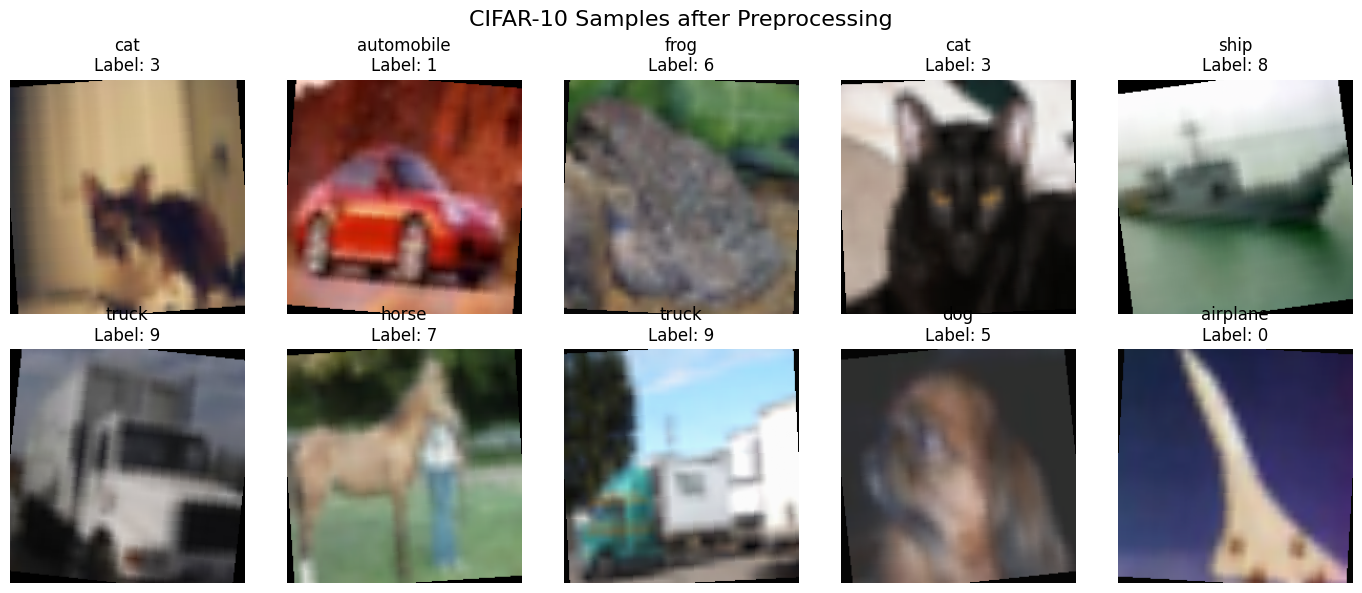

===== KẾT QUẢ TRỰC QUAN HÓA =====
Số ảnh hiển thị : 10
Kích thước ảnh  : 224 x 224
Đã lưu hình tại :
C:\Users\LAM LINH\OneDrive\Tài liệu\TQHDL\UTH-Deep-Learning-nhom2\Practice_2\results\figures\densenet121_input_samples.png


In [19]:
# ============================================================
# TRỰC QUAN HÓA DỮ LIỆU ĐẦU VÀO
# ============================================================

def denormalize_image(image):
    """
    Khôi phục ảnh đã Normalize theo ImageNet
    về khoảng giá trị [0, 1] để hiển thị.
    """
    mean = torch.tensor(
        IMAGENET_MEAN,
        dtype=image.dtype
    ).view(3, 1, 1)

    std = torch.tensor(
        IMAGENET_STD,
        dtype=image.dtype
    ).view(3, 1, 1)

    image = image.cpu() * std + mean

    return image.clamp(0, 1)


# Hiển thị 10 ảnh đầu tiên trong batch
fig, axes = plt.subplots(
    2,
    5,
    figsize=(14, 6)
)

for i, ax in enumerate(axes.flat):

    image = denormalize_image(images[i])

    # [C, H, W] -> [H, W, C]
    image = image.permute(1, 2, 0).numpy()

    label_index = labels[i].item()
    label_name = class_names[label_index]

    ax.imshow(image)
    ax.set_title(
        f"{label_name}\nLabel: {label_index}"
    )
    ax.axis("off")


plt.suptitle(
    "CIFAR-10 Samples after Preprocessing",
    fontsize=16
)

plt.tight_layout()

# ============================================================
# LƯU HÌNH KẾT QUẢ
# ============================================================

figure_dir = (
    PROJECT_DIR
    / "results"
    / "figures"
)

figure_dir.mkdir(
    parents=True,
    exist_ok=True
)

figure_path = (
    figure_dir
    / "densenet121_input_samples.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("===== KẾT QUẢ TRỰC QUAN HÓA =====")
print("Số ảnh hiển thị : 10")
print("Kích thước ảnh  : 224 x 224")
print("Đã lưu hình tại :")
print(figure_path)

# 2. Xây dựng mô hình DenseNet-121 Pre-trained
## 2.1. Tải mô hình và thay đổi Classifier
DenseNet-121 pre-trained được sử dụng làm mô hình nền cho bài toán phân loại CIFAR-10.
Mô hình gốc được huấn luyện trên ImageNet với **1000 lớp đầu ra**.
Trong khi đó, CIFAR-10 chỉ có **10 lớp**, vì vậy lớp phân loại cuối
`model.classifier` cần được thay đổi từ 1000 xuống 10 output features.
Quá trình này cho phép tận dụng các đặc trưng đã học từ mô hình pre-trained
và điều chỉnh mô hình cho bài toán mới.

In [20]:
# ============================================================
# DENSENET-121 PRE-TRAINED VÀ CLASSIFIER
# ============================================================

from torchvision import models


# ------------------------------------------------------------
# 1. DenseNet-121 gốc pre-trained trên ImageNet
# ------------------------------------------------------------

weights = models.DenseNet121_Weights.DEFAULT

original_model = models.densenet121(
    weights=weights
)

original_classifier = original_model.classifier


# ------------------------------------------------------------
# 2. DenseNet-121 được điều chỉnh cho CIFAR-10
#    Sử dụng module densenet121.py của Lam Linh
# ------------------------------------------------------------

model = build_densenet121(
    num_classes=10,
    pretrained=True,
    freeze_backbone=True
)

adapted_classifier = model.classifier


# ------------------------------------------------------------
# 3. So sánh classifier trước và sau khi điều chỉnh
# ------------------------------------------------------------

print("===== DENSENET-121 PRE-TRAINED =====")

print("\nClassifier gốc (ImageNet):")
print(original_classifier)

print("\nClassifier sau khi điều chỉnh cho CIFAR-10:")
print(adapted_classifier)

print("\n===== SO SÁNH =====")
print(
    f"Input features       : "
    f"{adapted_classifier.in_features}"
)

print(
    f"Output gốc ImageNet  : "
    f"{original_classifier.out_features}"
)

print(
    f"Output mới CIFAR-10  : "
    f"{adapted_classifier.out_features}"
)


# ------------------------------------------------------------
# 4. Kiểm tra điều kiện
# ------------------------------------------------------------

assert original_classifier.out_features == 1000
assert adapted_classifier.out_features == 10

print("\nKiểm tra thành công: classifier đã được thay từ 1000 → 10 lớp.")

===== DENSENET-121 PRE-TRAINED =====

Classifier gốc (ImageNet):
Linear(in_features=1024, out_features=1000, bias=True)

Classifier sau khi điều chỉnh cho CIFAR-10:
Linear(in_features=1024, out_features=10, bias=True)

===== SO SÁNH =====
Input features       : 1024
Output gốc ImageNet  : 1000
Output mới CIFAR-10  : 10

Kiểm tra thành công: classifier đã được thay từ 1000 → 10 lớp.


## 2.2. Khảo sát kiến trúc và số tham số DenseNet-121
Sau khi thay đổi classifier, cấu trúc của DenseNet-121 được kiểm tra
để xác định các thành phần chính của mô hình.
DenseNet-121 gồm phần trích xuất đặc trưng `features` với các Dense Block
và Transition Layer, sau đó là lớp `classifier` dùng để thực hiện phân loại.
Ở bước này, tiến hành:
- Kiểm tra các thành phần chính trong `model.features`.
- Xác định vị trí các Dense Block và Transition Layer.
- Tính tổng số tham số của mô hình.
- Kiểm tra số tham số đang được phép huấn luyện.

In [21]:
# ============================================================
# KHẢO SÁT KIẾN TRÚC DENSENET-121
# ============================================================

print("===== CẤU TRÚC CHÍNH CỦA DENSENET-121 =====")

for name, module in model.features.named_children():
    print(f"{name:<12} -> {module.__class__.__name__}")

print("\nClassifier:")
print(model.classifier)


# ============================================================
# THỐNG KÊ PARAMETERS
# ============================================================

total_params, trainable_params = count_parameters(model)

frozen_params = total_params - trainable_params

print("\n===== THỐNG KÊ PARAMETERS =====")
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"Frozen parameters    : {frozen_params:,}")

print(
    f"Trainable ratio      : "
    f"{trainable_params / total_params * 100:.4f}%"
)

===== CẤU TRÚC CHÍNH CỦA DENSENET-121 =====
conv0        -> Conv2d
norm0        -> BatchNorm2d
relu0        -> ReLU
pool0        -> MaxPool2d
denseblock1  -> _DenseBlock
transition1  -> _Transition
denseblock2  -> _DenseBlock
transition2  -> _Transition
denseblock3  -> _DenseBlock
transition3  -> _Transition
denseblock4  -> _DenseBlock
norm5        -> BatchNorm2d

Classifier:
Linear(in_features=1024, out_features=10, bias=True)

===== THỐNG KÊ PARAMETERS =====
Total parameters     : 6,964,106
Trainable parameters : 10,250
Frozen parameters    : 6,953,856
Trainable ratio      : 0.1472%


## 2.3. Kiểm tra đóng băng Backbone cho Transfer Learning
Trong giai đoạn Transfer Learning, các tham số của phần trích xuất đặc trưng
(`model.features`) được giữ cố định và chỉ classifier mới được huấn luyện.
Việc kiểm tra `requires_grad` giúp xác nhận:
- Toàn bộ backbone đã được đóng băng.
- `classifier.weight` và `classifier.bias` vẫn được phép cập nhật.
- Optimizer ở giai đoạn Transfer Learning chỉ cần tối ưu các tham số của classifier.

In [22]:
# ============================================================
# KIỂM TRA FREEZE BACKBONE
# ============================================================

# Kiểm tra toàn bộ phần features
backbone_frozen = all(
    not param.requires_grad
    for param in model.features.parameters()
)

# Kiểm tra classifier
classifier_trainable = all(
    param.requires_grad
    for param in model.classifier.parameters()
)

# Lấy danh sách các parameter đang được phép học
trainable_names = [
    name
    for name, param in model.named_parameters()
    if param.requires_grad
]


print("===== KIỂM TRA FREEZE BACKBONE =====")
print(f"Backbone đã đóng băng : {backbone_frozen}")
print(f"Classifier được train : {classifier_trainable}")

print("\nCác parameter đang được huấn luyện:")

for name in trainable_names:
    print(f" - {name}")


# ============================================================
# KIỂM TRA TỰ ĐỘNG
# ============================================================

assert backbone_frozen, \
    "Backbone chưa được đóng băng hoàn toàn."

assert classifier_trainable, \
    "Classifier chưa được mở để huấn luyện."

assert set(trainable_names) == {
    "classifier.weight",
    "classifier.bias"
}, "Có parameter ngoài classifier đang được huấn luyện."


print("\nKiểm tra thành công: chỉ classifier được huấn luyện.")

===== KIỂM TRA FREEZE BACKBONE =====
Backbone đã đóng băng : True
Classifier được train : True

Các parameter đang được huấn luyện:
 - classifier.weight
 - classifier.bias

Kiểm tra thành công: chỉ classifier được huấn luyện.


## 2.4. Kiểm tra Forward Pass với dữ liệu CIFAR-10

Trước khi huấn luyện, một batch ảnh thực tế từ CIFAR-10 được đưa qua
DenseNet-121 để kiểm tra tính tương thích giữa Data Pipeline và mô hình.
Với Batch Size = 32 và CIFAR-10 gồm 10 lớp:
- Input của mô hình có kích thước `[32, 3, 224, 224]`.
- Output mong đợi có kích thước `[32, 10]`.
- Mỗi hàng của output chứa 10 logits tương ứng với 10 lớp CIFAR-10.

Ở bước kiểm tra này, mô hình được đặt ở chế độ `eval()` và không tính gradient.
Classifier mới chưa được huấn luyện nên chưa sử dụng kết quả này để đánh giá độ chính xác.

In [23]:
# ============================================================
# FORWARD PASS VỚI MỘT BATCH CIFAR-10
# ============================================================

model = model.to(device)

# Sử dụng batch CIFAR-10 đã lấy từ train_loader
input_images = images.to(device)
input_labels = labels.to(device)

model.eval()

with torch.no_grad():
    logits = model(input_images)

print("===== FORWARD PASS =====")
print(f"Input shape        : {input_images.shape}")
print(f"Output shape       : {logits.shape}")
print(f"Output dtype       : {logits.dtype}")
print(f"Number of classes  : {logits.shape[1]}")


# ============================================================
# KIỂM TRA TỰ ĐỘNG
# ============================================================

assert input_images.shape == (32, 3, 224, 224), \
    "Kích thước input không đúng."

assert logits.shape == (32, 10), \
    "Output của DenseNet-121 phải có 10 lớp."

assert torch.isfinite(logits).all(), \
    "Output chứa NaN hoặc Infinity."


print("\nKiểm tra thành công:")
print("DenseNet-121 nhận đúng dữ liệu CIFAR-10 và trả về 10 logits cho mỗi ảnh.")

===== FORWARD PASS =====
Input shape        : torch.Size([32, 3, 224, 224])
Output shape       : torch.Size([32, 10])
Output dtype       : torch.float32
Number of classes  : 10

Kiểm tra thành công:
DenseNet-121 nhận đúng dữ liệu CIFAR-10 và trả về 10 logits cho mỗi ảnh.


# 3. Thiết lập Fine-tuning cho DenseNet-121
## 3.1. Mở DenseBlock cuối để Fine-tuning
Sau giai đoạn Transfer Learning, một phần của backbone được mở để mô hình
có thể điều chỉnh các đặc trưng đã học trước cho dữ liệu CIFAR-10.
Trong bài này, `denseblock4` — Dense Block cuối của DenseNet-121 —
được mở cùng với `classifier`.
Các layer trước `denseblock4` vẫn được giữ đóng băng nhằm:
- Giữ lại phần lớn các đặc trưng pre-trained.
- Giảm số lượng tham số cần cập nhật.
- Hạn chế chi phí huấn luyện so với Fine-tuning toàn bộ mạng.
Sau khi mở `denseblock4`, số lượng trainable parameters sẽ tăng đáng kể
so với giai đoạn Transfer Learning.

In [24]:
# ============================================================
# THIẾT LẬP FINE-TUNING DENSENET-121
# ============================================================

model_ft_demo = build_densenet121(
    num_classes=10,
    pretrained=True,
    freeze_backbone=True
)

# Số trainable parameters trước khi Fine-tuning
_, transfer_trainable_params = count_parameters(model_ft_demo)


# ------------------------------------------------------------
# Mở DenseBlock cuối + Classifier
# ------------------------------------------------------------

enable_finetuning_last_block(model_ft_demo)


# ------------------------------------------------------------
# Thống kê parameters sau khi Fine-tuning
# ------------------------------------------------------------

total_ft_params, finetune_trainable_params = count_parameters(
    model_ft_demo
)

frozen_ft_params = (
    total_ft_params - finetune_trainable_params
)


print("===== FINE-TUNING DENSENET-121 =====")

print("\nTrainable parameters:")
print(
    f"Transfer Learning : "
    f"{transfer_trainable_params:,}"
)
print(
    f"Fine-tuning       : "
    f"{finetune_trainable_params:,}"
)

print(
    f"\nFrozen parameters : "
    f"{frozen_ft_params:,}"
)

print(
    f"Trainable ratio   : "
    f"{finetune_trainable_params / total_ft_params * 100:.2f}%"
)


# ============================================================
# KIỂM TRA TRẠNG THÁI CÁC PHẦN CỦA MODEL
# ============================================================

conv0_trainable = any(
    p.requires_grad
    for p in model_ft_demo.features.conv0.parameters()
)

denseblock4_trainable = all(
    p.requires_grad
    for p in model_ft_demo.features.denseblock4.parameters()
)

classifier_trainable_ft = all(
    p.requires_grad
    for p in model_ft_demo.classifier.parameters()
)


print("\n===== KIỂM TRA LAYER =====")
print(
    f"conv0 được train       : "
    f"{conv0_trainable}"
)
print(
    f"denseblock4 được train : "
    f"{denseblock4_trainable}"
)
print(
    f"classifier được train  : "
    f"{classifier_trainable_ft}"
)


# ============================================================
# KIỂM TRA TỰ ĐỘNG
# ============================================================

assert conv0_trainable is False
assert denseblock4_trainable is True
assert classifier_trainable_ft is True

assert (
    finetune_trainable_params
    > transfer_trainable_params
)

print(
    "\nKiểm tra thành công: "
    "denseblock4 và classifier đã được mở để Fine-tuning."
)

===== FINE-TUNING DENSENET-121 =====

Trainable parameters:
Transfer Learning : 10,250
Fine-tuning       : 2,168,330

Frozen parameters : 4,795,776
Trainable ratio   : 31.14%

===== KIỂM TRA LAYER =====
conv0 được train       : False
denseblock4 được train : True
classifier được train  : True

Kiểm tra thành công: denseblock4 và classifier đã được mở để Fine-tuning.


## 3.2. So sánh số tham số giữa Transfer Learning và Fine-tuning
Để trực quan hóa mức độ thay đổi của mô hình, số lượng trainable parameters
được so sánh giữa hai giai đoạn:
- Transfer Learning: chỉ huấn luyện classifier.
- Fine-tuning: huấn luyện thêm `denseblock4` cùng classifier.

Biểu đồ cho thấy Fine-tuning làm tăng đáng kể số tham số cần cập nhật,
đồng nghĩa với khả năng thích nghi cao hơn nhưng chi phí huấn luyện cũng lớn hơn.

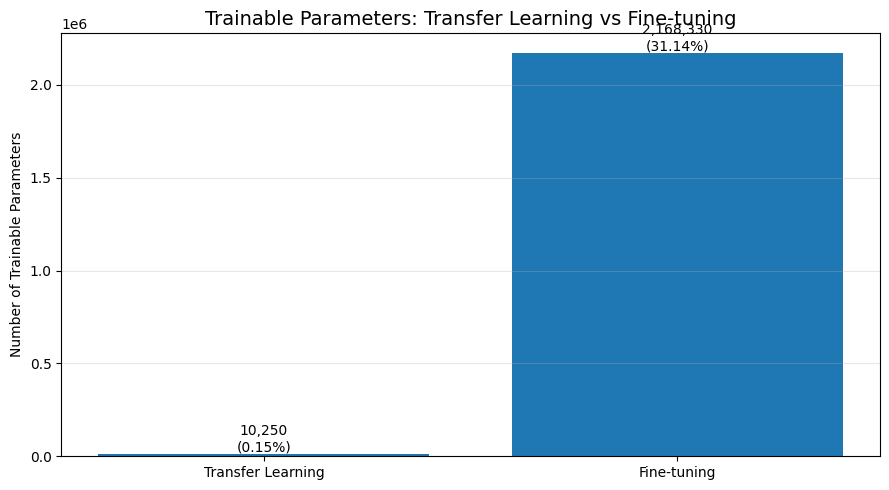

===== SO SÁNH PARAMETERS =====
Transfer Learning : 10,250 (0.1472%)
Fine-tuning       : 2,168,330 (31.14%)

Đã lưu biểu đồ tại:
C:\Users\LAM LINH\OneDrive\Tài liệu\TQHDL\UTH-Deep-Learning-nhom2\Practice_2\results\figures\densenet121_trainable_parameters.png


In [25]:
# ============================================================
# TRỰC QUAN HÓA TRAINABLE PARAMETERS
# ============================================================

stages = [
    "Transfer Learning",
    "Fine-tuning"
]

trainable_counts = [
    transfer_trainable_params,
    finetune_trainable_params
]

trainable_ratios = [
    transfer_trainable_params / total_ft_params * 100,
    finetune_trainable_params / total_ft_params * 100
]


fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    stages,
    trainable_counts
)

ax.set_title(
    "Trainable Parameters: Transfer Learning vs Fine-tuning",
    fontsize=14
)

ax.set_ylabel("Number of Trainable Parameters")

ax.grid(
    axis="y",
    alpha=0.3
)


# Hiển thị số parameter và tỷ lệ trên từng cột
for bar, count, ratio in zip(
    bars,
    trainable_counts,
    trainable_ratios
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({ratio:.2f}%)",
        ha="center",
        va="bottom"
    )


plt.tight_layout()


# ============================================================
# LƯU HÌNH
# ============================================================

figure_path = (
    PROJECT_DIR
    / "results"
    / "figures"
    / "densenet121_trainable_parameters.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("===== SO SÁNH PARAMETERS =====")
print(
    f"Transfer Learning : "
    f"{transfer_trainable_params:,} "
    f"({trainable_ratios[0]:.4f}%)"
)

print(
    f"Fine-tuning       : "
    f"{finetune_trainable_params:,} "
    f"({trainable_ratios[1]:.2f}%)"
)

print("\nĐã lưu biểu đồ tại:")
print(figure_path)

# 4. Thiết kế thí nghiệm huấn luyện
## 4.1. Thiết lập cấu hình chung
DenseNet-121 được thực nghiệm với hai Batch Size:
| Experiment | Batch Size |
|------------|------------|
| DenseNet-121 A | 32 |
| DenseNet-121 B | 64 |

Để đảm bảo so sánh công bằng, hai thí nghiệm sử dụng cùng:
- Random Seed.
- Learning Rate.
- Optimizer.
- Loss Function.
- Số epoch Transfer Learning.
- Số epoch Fine-tuning.
- Train/Validation split.

Quy trình huấn luyện của mỗi thí nghiệm gồm hai giai đoạn:
- Đóng băng backbone và chỉ huấn luyện classifier.
- Nạp lại checkpoint tốt nhất của giai đoạn Transfer Learning,
sau đó mở `denseblock4` và classifier để tiếp tục huấn luyện.

In [26]:
# ============================================================
# CẤU HÌNH THÍ NGHIỆM DENSENET-121
# ============================================================

import inspect

NUM_CLASSES = 10
IMAGE_SIZE = 224

# Biến duy nhất thay đổi giữa hai thí nghiệm
BATCH_SIZE_A = 32
BATCH_SIZE_B = 64

# Các hyperparameter giữ cố định
LEARNING_RATE = 0.001
OPTIMIZER_NAME = "Adam"

TRANSFER_EPOCHS = 2
FINETUNE_EPOCHS = 3

TOTAL_EPOCHS = (
    TRANSFER_EPOCHS
    + FINETUNE_EPOCHS
)

# Loss cho bài toán phân loại 10 lớp
criterion = nn.CrossEntropyLoss()


# ============================================================
# THƯ MỤC KẾT QUẢ
# ============================================================

CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"
RUNS_DIR = PROJECT_DIR / "runs" / "densenet121"

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RUNS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# IN CẤU HÌNH
# ============================================================

print("===== CẤU HÌNH THÍ NGHIỆM DENSENET-121 =====")

print(f"Experiment A      : Batch Size = {BATCH_SIZE_A}")
print(f"Experiment B      : Batch Size = {BATCH_SIZE_B}")

print(f"\nOptimizer         : {OPTIMIZER_NAME}")
print(f"Learning Rate     : {LEARNING_RATE}")
print(f"Loss Function     : {criterion.__class__.__name__}")

print(f"\nTransfer Epochs   : {TRANSFER_EPOCHS}")
print(f"Fine-tuning Epochs: {FINETUNE_EPOCHS}")
print(f"Total Epochs      : {TOTAL_EPOCHS}")

print(f"\nRandom Seed       : {SEED}")
print(f"Image Size        : {IMAGE_SIZE} x {IMAGE_SIZE}")
print(f"Number of Classes : {NUM_CLASSES}")


# ============================================================
# KIỂM TRA TRAINING ENGINE CỦA NHÓM
# ============================================================

print("\n===== TRAINING ENGINE DÙNG CHUNG =====")
print("Function:", train_model.__name__)
print("Signature:")
print(inspect.signature(train_model))

===== CẤU HÌNH THÍ NGHIỆM DENSENET-121 =====
Experiment A      : Batch Size = 32
Experiment B      : Batch Size = 64

Optimizer         : Adam
Learning Rate     : 0.001
Loss Function     : CrossEntropyLoss

Transfer Epochs   : 2
Fine-tuning Epochs: 3
Total Epochs      : 5

Random Seed       : 42
Image Size        : 224 x 224
Number of Classes : 10

===== TRAINING ENGINE DÙNG CHUNG =====
Function: train_model
Signature:
(model, train_loader, val_loader, criterion, optimizer, num_epochs, log_dir, checkpoint_path)


## 4.2. Tạo DataLoader cho Batch Size 32 và 64
Hai thí nghiệm phải sử dụng cùng dữ liệu Train và Validation,
chỉ thay đổi Batch Size.

Vì vậy, hai DataLoader được tạo với:
- Cùng Random Seed = 42.
- Cùng Validation Ratio = 0.10.
- Cùng kích thước ảnh 224 × 224.
- Cùng Data Pipeline.
- Chỉ khác Batch Size: 32 và 64.

Sau khi tạo DataLoader, tiến hành kiểm tra số lượng mẫu,
số batch và các chỉ số Train/Validation để đảm bảo hai thí nghiệm
sử dụng cùng một cách chia dữ liệu.

In [27]:
# ============================================================
# TẠO DATALOADER CHO HAI THÍ NGHIỆM
# ============================================================

config_bs32 = DataConfig(
    data_dir=PROJECT_DIR / "data",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE_A,
    val_ratio=0.10,
    num_workers=2,
    seed=SEED,
)

config_bs64 = DataConfig(
    data_dir=PROJECT_DIR / "data",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE_B,
    val_ratio=0.10,
    num_workers=2,
    seed=SEED,
)


data_bs32 = build_dataloaders(config_bs32)
data_bs64 = build_dataloaders(config_bs64)


# ============================================================
# LẤY DATALOADER
# ============================================================

train_loader_32 = data_bs32["train_loader"]
val_loader_32 = data_bs32["val_loader"]

train_loader_64 = data_bs64["train_loader"]
val_loader_64 = data_bs64["val_loader"]


# ============================================================
# KIỂM TRA KÍCH THƯỚC DATASET
# ============================================================

print("===== SO SÁNH DATALOADER =====")

print("\nBatch Size 32:")
print(
    f"Train samples      : "
    f"{len(train_loader_32.dataset):,}"
)
print(
    f"Validation samples : "
    f"{len(val_loader_32.dataset):,}"
)
print(
    f"Number of batches  : "
    f"{len(train_loader_32)}"
)

print("\nBatch Size 64:")
print(
    f"Train samples      : "
    f"{len(train_loader_64.dataset):,}"
)
print(
    f"Validation samples : "
    f"{len(val_loader_64.dataset):,}"
)
print(
    f"Number of batches  : "
    f"{len(train_loader_64)}"
)


# ============================================================
# KIỂM TRA MỘT BATCH
# ============================================================

images_32, labels_32 = next(iter(train_loader_32))
images_64, labels_64 = next(iter(train_loader_64))

print("\n===== KÍCH THƯỚC BATCH =====")
print(
    f"Batch 32 images : {images_32.shape}"
)
print(
    f"Batch 32 labels : {labels_32.shape}"
)

print(
    f"Batch 64 images : {images_64.shape}"
)
print(
    f"Batch 64 labels : {labels_64.shape}"
)


# ============================================================
# KIỂM TRA CÙNG TRAIN / VALIDATION SPLIT
# ============================================================

train_same_split = True
val_same_split = True

train_dataset_32 = data_bs32["train_dataset"]
train_dataset_64 = data_bs64["train_dataset"]

val_dataset_32 = data_bs32["val_dataset"]
val_dataset_64 = data_bs64["val_dataset"]


if (
    hasattr(train_dataset_32, "indices")
    and hasattr(train_dataset_64, "indices")
):
    train_same_split = (
        list(train_dataset_32.indices)
        == list(train_dataset_64.indices)
    )

if (
    hasattr(val_dataset_32, "indices")
    and hasattr(val_dataset_64, "indices")
):
    val_same_split = (
        list(val_dataset_32.indices)
        == list(val_dataset_64.indices)
    )


print("\n===== KIỂM TRA SPLIT =====")
print(
    f"Cùng Train split      : {train_same_split}"
)
print(
    f"Cùng Validation split : {val_same_split}"
)


# ============================================================
# ASSERT
# ============================================================

assert len(train_loader_32.dataset) == 45000
assert len(train_loader_64.dataset) == 45000

assert len(val_loader_32.dataset) == 5000
assert len(val_loader_64.dataset) == 5000

assert images_32.shape[0] == 32
assert images_64.shape[0] == 64

assert train_same_split
assert val_same_split


print(
    "\nKiểm tra thành công: "
    "hai thí nghiệm sử dụng cùng dữ liệu "
    "và chỉ khác Batch Size."
)

===== SO SÁNH DATALOADER =====

Batch Size 32:
Train samples      : 45,000
Validation samples : 5,000
Number of batches  : 1407

Batch Size 64:
Train samples      : 45,000
Validation samples : 5,000
Number of batches  : 704

===== KÍCH THƯỚC BATCH =====
Batch 32 images : torch.Size([32, 3, 224, 224])
Batch 32 labels : torch.Size([32])
Batch 64 images : torch.Size([64, 3, 224, 224])
Batch 64 labels : torch.Size([64])

===== KIỂM TRA SPLIT =====
Cùng Train split      : True
Cùng Validation split : True

Kiểm tra thành công: hai thí nghiệm sử dụng cùng dữ liệu và chỉ khác Batch Size.


## 4.3. Xây dựng quy trình huấn luyện hai giai đoạn
Mỗi thí nghiệm DenseNet-121 được huấn luyện theo hai giai đoạn:
### Giai đoạn 1 — Transfer Learning
- Tải DenseNet-121 pre-trained.
- Đóng băng toàn bộ backbone.
- Chỉ huấn luyện classifier.
- Lưu checkpoint có Validation Accuracy tốt nhất.
### Giai đoạn 2 — Fine-tuning
- Nạp lại checkpoint tốt nhất của giai đoạn Transfer Learning.
- Mở `denseblock4` và `classifier`.
- Khởi tạo lại optimizer để các tham số vừa được mở có thể được cập nhật.
- Tiếp tục huấn luyện và lưu checkpoint tốt nhất.

Thời gian huấn luyện được tính cho toàn bộ hai giai đoạn.
Nếu CUDA khả dụng, mức sử dụng GPU memory tối đa cũng được ghi nhận.

In [30]:
# ============================================================
# HÀM HỖ TRỢ CHECKPOINT
# ============================================================

import shutil


def load_checkpoint_to_model(model, checkpoint_path, device):
    """
    Nạp checkpoint được tạo bởi trainer.py của nhóm
    vào model và trả về thông tin checkpoint.
    """
    checkpoint = torch.load(
        checkpoint_path,
        map_location=device
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    return checkpoint


# ============================================================
# HÀM CHẠY MỘT THÍ NGHIỆM DENSENET-121
# ============================================================

def run_densenet_experiment(
    batch_size,
    train_loader,
    val_loader
):
    """
    DenseNet-121:
    1. Transfer Learning
    2. Fine-tuning denseblock4 + classifier
    """

    print("=" * 65)
    print(
        f"DENSENET-121 EXPERIMENT | "
        f"BATCH SIZE = {batch_size}"
    )
    print("=" * 65)

    # --------------------------------------------------------
    # Reset seed
    # --------------------------------------------------------

    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)


    # --------------------------------------------------------
    # Tạo model mới
    # --------------------------------------------------------

    experiment_model = build_densenet121(
        num_classes=NUM_CLASSES,
        pretrained=True,
        freeze_backbone=True
    )


    # --------------------------------------------------------
    # Đường dẫn riêng cho experiment
    # --------------------------------------------------------

    experiment_name = (
        f"densenet121_bs{batch_size}"
    )

    transfer_log_dir = (
        RUNS_DIR
        / experiment_name
        / "transfer"
    )

    finetune_log_dir = (
        RUNS_DIR
        / experiment_name
        / "finetune"
    )

    transfer_checkpoint = (
        CHECKPOINT_DIR
        / f"{experiment_name}_transfer_best.pth"
    )

    finetune_checkpoint = (
        CHECKPOINT_DIR
        / f"{experiment_name}_finetune_best.pth"
    )

    final_checkpoint = (
        CHECKPOINT_DIR
        / f"{experiment_name}_best.pth"
    )


    # --------------------------------------------------------
    # Đo thời gian / GPU memory
    # --------------------------------------------------------

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    start_time = time.perf_counter()


    # ========================================================
    # STAGE 1 — TRANSFER LEARNING
    # ========================================================

    print("\n[STAGE 1] TRANSFER LEARNING")
    print("-" * 45)

    _, transfer_params = count_parameters(
        experiment_model
    )

    print(
        f"Trainable parameters: "
        f"{transfer_params:,}"
    )

    optimizer_transfer = optim.Adam(
        filter(
            lambda p: p.requires_grad,
            experiment_model.parameters()
        ),
        lr=LEARNING_RATE
    )

    history_transfer = train_model(
        model=experiment_model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer_transfer,
        num_epochs=TRANSFER_EPOCHS,
        log_dir=str(transfer_log_dir),
        checkpoint_path=str(
            transfer_checkpoint
        ),
    )


    # --------------------------------------------------------
    # Nạp checkpoint Transfer Learning tốt nhất
    # --------------------------------------------------------

    transfer_ckpt = load_checkpoint_to_model(
        experiment_model,
        transfer_checkpoint,
        device
    )

    transfer_best_acc = transfer_ckpt[
        "val_acc"
    ]

    print(
        f"\nBest Transfer Val Acc: "
        f"{transfer_best_acc:.2f}%"
    )


    # ========================================================
    # STAGE 2 — FINE-TUNING
    # ========================================================

    print("\n[STAGE 2] FINE-TUNING")
    print("-" * 45)

    enable_finetuning_last_block(
        experiment_model
    )

    _, finetune_params = count_parameters(
        experiment_model
    )

    print(
        f"Trainable parameters: "
        f"{finetune_params:,}"
    )


    # QUAN TRỌNG:
    # tạo optimizer mới sau khi mở denseblock4
    optimizer_finetune = optim.Adam(
        filter(
            lambda p: p.requires_grad,
            experiment_model.parameters()
        ),
        lr=LEARNING_RATE
    )

    history_finetune = train_model(
        model=experiment_model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer_finetune,
        num_epochs=FINETUNE_EPOCHS,
        log_dir=str(finetune_log_dir),
        checkpoint_path=str(
            finetune_checkpoint
        ),
    )


    # --------------------------------------------------------
    # Lấy best Fine-tuning checkpoint
    # --------------------------------------------------------

    finetune_ckpt = torch.load(
        finetune_checkpoint,
        map_location=device
    )

    finetune_best_acc = finetune_ckpt[
        "val_acc"
    ]


    # ========================================================
    # CHỌN CHECKPOINT TỐT NHẤT TOÀN BỘ
    # ========================================================

    if finetune_best_acc >= transfer_best_acc:

        best_stage = "Fine-tuning"
        best_val_acc = finetune_best_acc
        best_source = finetune_checkpoint

    else:

        best_stage = "Transfer Learning"
        best_val_acc = transfer_best_acc
        best_source = transfer_checkpoint


    shutil.copy2(
        best_source,
        final_checkpoint
    )


    # --------------------------------------------------------
    # Kết thúc timing
    # --------------------------------------------------------

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    training_time = (
        time.perf_counter()
        - start_time
    )


    # --------------------------------------------------------
    # GPU memory
    # --------------------------------------------------------

    if torch.cuda.is_available():

        peak_memory_mb = (
            torch.cuda.max_memory_allocated()
            / (1024 ** 2)
        )

    else:

        peak_memory_mb = None


    # ========================================================
    # GỘP HISTORY
    # ========================================================

    history = {
        "train_loss":
            history_transfer["train_loss"]
            + history_finetune["train_loss"],

        "train_acc":
            history_transfer["train_acc"]
            + history_finetune["train_acc"],

        "val_loss":
            history_transfer["val_loss"]
            + history_finetune["val_loss"],

        "val_acc":
            history_transfer["val_acc"]
            + history_finetune["val_acc"],
    }


    # ========================================================
    # KẾT QUẢ
    # ========================================================

    result = {
        "batch_size": batch_size,

        "history": history,

        "history_transfer":
            history_transfer,

        "history_finetune":
            history_finetune,

        "transfer_best_acc":
            transfer_best_acc,

        "finetune_best_acc":
            finetune_best_acc,

        "best_val_acc":
            best_val_acc,

        "best_stage":
            best_stage,

        "training_time":
            training_time,

        "peak_memory_mb":
            peak_memory_mb,

        "checkpoint":
            str(final_checkpoint),
    }

    return result

# ============================================================
# KIỂM TRA QUY TRÌNH TRƯỚC KHI TRAIN
# ============================================================

print("===== KIỂM TRA TRAINING PIPELINE =====")

print(
    "run_densenet_experiment:",
    callable(run_densenet_experiment)
)

print(
    "load_checkpoint_to_model:",
    callable(load_checkpoint_to_model)
)

print("\nCheckpoint directory:")
print(CHECKPOINT_DIR)

print("\nTensorBoard directory:")
print(RUNS_DIR)

print("\nCấu hình:")
print(
    f"Transfer Learning : "
    f"{TRANSFER_EPOCHS} epochs"
)
print(
    f"Fine-tuning       : "
    f"{FINETUNE_EPOCHS} epochs"
)
print(
    f"Total             : "
    f"{TOTAL_EPOCHS} epochs"
)

print(
    f"Optimizer         : "
    f"{OPTIMIZER_NAME}"
)
print(
    f"Learning Rate     : "
    f"{LEARNING_RATE}"
)

print("\nPipeline đã sẵn sàng.")

===== KIỂM TRA TRAINING PIPELINE =====
run_densenet_experiment: True
load_checkpoint_to_model: True

Checkpoint directory:
C:\Users\LAM LINH\OneDrive\Tài liệu\TQHDL\UTH-Deep-Learning-nhom2\Practice_2\checkpoints

TensorBoard directory:
C:\Users\LAM LINH\OneDrive\Tài liệu\TQHDL\UTH-Deep-Learning-nhom2\Practice_2\runs\densenet121

Cấu hình:
Transfer Learning : 2 epochs
Fine-tuning       : 3 epochs
Total             : 5 epochs
Optimizer         : Adam
Learning Rate     : 0.001

Pipeline đã sẵn sàng.


## 4.4. Kiểm tra nhanh Training Pipeline (Smoke Test)
Trước khi chạy thí nghiệm chính trên toàn bộ tập dữ liệu, một Smoke Test
được thực hiện trên một tập dữ liệu nhỏ.
Mục đích của bước này là kiểm tra toàn bộ Training Pipeline:
- Forward Pass.
- Tính CrossEntropyLoss.
- Backpropagation và cập nhật weights.
- Validation.
- TensorBoard logging.
- Lưu Best Checkpoint.

Smoke Test chỉ dùng để kiểm tra kỹ thuật và **không được sử dụng làm kết quả thực nghiệm cuối cùng**.

In [32]:
# ============================================================
# TẠO DỮ LIỆU NHỎ CHO SMOKE TEST
# ============================================================

from torch.utils.data import DataLoader, Subset


# Lấy một lượng nhỏ dữ liệu
smoke_train_dataset = Subset(
    data_bs32["train_dataset"],
    range(128)
)

smoke_val_dataset = Subset(
    data_bs32["val_dataset"],
    range(64)
)


smoke_train_loader = DataLoader(
    smoke_train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

smoke_val_loader = DataLoader(
    smoke_val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)


print("===== SMOKE TEST DATA =====")
print(
    f"Train samples      : "
    f"{len(smoke_train_dataset)}"
)
print(
    f"Validation samples : "
    f"{len(smoke_val_dataset)}"
)
print(
    f"Train batches      : "
    f"{len(smoke_train_loader)}"
)
print(
    f"Validation batches : "
    f"{len(smoke_val_loader)}"
)
# ============================================================
# SMOKE TEST TRAINING ENGINE
# ============================================================

smoke_model = build_densenet121(
    num_classes=NUM_CLASSES,
    pretrained=True,
    freeze_backbone=True
)


smoke_optimizer = optim.Adam(
    filter(
        lambda p: p.requires_grad,
        smoke_model.parameters()
    ),
    lr=LEARNING_RATE
)


smoke_checkpoint = (
    CHECKPOINT_DIR
    / "densenet121_smoke_test.pth"
)

smoke_log_dir = (
    RUNS_DIR
    / "smoke_test"
)


print("===== BẮT ĐẦU SMOKE TEST =====")

smoke_history = train_model(
    model=smoke_model,
    train_loader=smoke_train_loader,
    val_loader=smoke_val_loader,
    criterion=criterion,
    optimizer=smoke_optimizer,
    num_epochs=1,
    log_dir=str(smoke_log_dir),
    checkpoint_path=str(smoke_checkpoint),
)


print("\n===== KẾT QUẢ SMOKE TEST =====")

print(
    f"Train Loss : "
    f"{smoke_history['train_loss'][0]:.4f}"
)

print(
    f"Train Acc  : "
    f"{smoke_history['train_acc'][0]:.2f}%"
)

print(
    f"Val Loss   : "
    f"{smoke_history['val_loss'][0]:.4f}"
)

print(
    f"Val Acc    : "
    f"{smoke_history['val_acc'][0]:.2f}%"
)

print(
    f"Checkpoint : "
    f"{smoke_checkpoint.exists()}"
)

===== SMOKE TEST DATA =====
Train samples      : 128
Validation samples : 64
Train batches      : 4
Validation batches : 2
===== BẮT ĐẦU SMOKE TEST =====

Epoch [1/1]


Validating: 100%|██████████| 2/2 [00:05<00:00,  2.70s/it]


Train Loss: 2.3320, Train Acc: 19.53%
Val Loss: 2.4143, Val Acc: 17.19%
Validation accuracy improved (0.00% --> 17.19%). Saving model...

===== KẾT QUẢ SMOKE TEST =====
Train Loss : 2.3320
Train Acc  : 19.53%
Val Loss   : 2.4143
Val Acc    : 17.19%
Checkpoint : True


## 4.5. Kiểm tra Checkpoint và TensorBoard
Sau Smoke Test, các artifact được kiểm tra trước khi chạy thí nghiệm chính.
Mục tiêu:
- Xác nhận checkpoint đã được lưu đúng định dạng.
- Kiểm tra các thông tin cần thiết trong checkpoint.
- Nạp lại weights vào một DenseNet-121 mới.
- Xác nhận TensorBoard event file đã được tạo.

Việc kiểm tra này đảm bảo quá trình
`Transfer Learning → Best Checkpoint → Fine-tuning`
có thể hoạt động ổn định trong thí nghiệm chính.

In [35]:
# ============================================================
# KIỂM TRA CHECKPOINT SAU SMOKE TEST
# ============================================================

checkpoint = torch.load(
    smoke_checkpoint,
    map_location=device
)

print("===== CHECKPOINT =====")
print("File tồn tại :", smoke_checkpoint.exists())
print("Các keys     :", list(checkpoint.keys()))

if "epoch" in checkpoint:
    print("Best epoch   :", checkpoint["epoch"])

if "val_acc" in checkpoint:
    print(
        f"Best Val Acc : "
        f"{checkpoint['val_acc']:.2f}%"
    )


# ============================================================
# KIỂM TRA MODEL STATE DICT
# ============================================================

assert "model_state_dict" in checkpoint, \
    "Checkpoint thiếu model_state_dict."

assert "optimizer_state_dict" in checkpoint, \
    "Checkpoint thiếu optimizer_state_dict."


print(
    "Số tensors trong model_state_dict:",
    len(checkpoint["model_state_dict"])
)


# ============================================================
# THỬ NẠP CHECKPOINT VÀO MODEL MỚI
# ============================================================

checkpoint_test_model = build_densenet121(
    num_classes=NUM_CLASSES,
    pretrained=True,
    freeze_backbone=True
)

load_checkpoint_to_model(
    checkpoint_test_model,
    smoke_checkpoint,
    device
)

print(
    "\nLoad checkpoint vào DenseNet-121 mới: THÀNH CÔNG"
)


# ============================================================
# KIỂM TRA TENSORBOARD EVENT FILE
# ============================================================

tensorboard_files = list(
    smoke_log_dir.glob("events.out.tfevents.*")
)

print("\n===== TENSORBOARD =====")
print(
    "Số event files :",
    len(tensorboard_files)
)

for file in tensorboard_files:
    print(" -", file.name)


assert len(tensorboard_files) > 0, \
    "Chưa tìm thấy TensorBoard event file."


print(
    "\nKiểm tra thành công: "
    "Checkpoint và TensorBoard đều hoạt động."
)
# ============================================================
# KIỂM TRA CHECKPOINT SAU SMOKE TEST
# ============================================================

checkpoint = torch.load(
    smoke_checkpoint,
    map_location=device
)

print("===== CHECKPOINT =====")
print("File tồn tại :", smoke_checkpoint.exists())
print("Các keys     :", list(checkpoint.keys()))

if "epoch" in checkpoint:
    print("Best epoch   :", checkpoint["epoch"])

if "val_acc" in checkpoint:
    print(
        f"Best Val Acc : "
        f"{checkpoint['val_acc']:.2f}%"
    )


# ============================================================
# KIỂM TRA MODEL STATE DICT
# ============================================================

assert "model_state_dict" in checkpoint, \
    "Checkpoint thiếu model_state_dict."

assert "optimizer_state_dict" in checkpoint, \
    "Checkpoint thiếu optimizer_state_dict."


print(
    "Số tensors trong model_state_dict:",
    len(checkpoint["model_state_dict"])
)


# ============================================================
# THỬ NẠP CHECKPOINT VÀO MODEL MỚI
# ============================================================

checkpoint_test_model = build_densenet121(
    num_classes=NUM_CLASSES,
    pretrained=True,
    freeze_backbone=True
)

load_checkpoint_to_model(
    checkpoint_test_model,
    smoke_checkpoint,
    device
)

print(
    "\nLoad checkpoint vào DenseNet-121 mới: THÀNH CÔNG"
)



===== CHECKPOINT =====
File tồn tại : True
Các keys     : ['epoch', 'model_state_dict', 'optimizer_state_dict', 'val_acc']
Best epoch   : 0
Best Val Acc : 17.19%
Số tensors trong model_state_dict: 727

Load checkpoint vào DenseNet-121 mới: THÀNH CÔNG

===== TENSORBOARD =====
Số event files : 1
 - events.out.tfevents.1786219304.LamLinn.4348.1

Kiểm tra thành công: Checkpoint và TensorBoard đều hoạt động.
===== CHECKPOINT =====
File tồn tại : True
Các keys     : ['epoch', 'model_state_dict', 'optimizer_state_dict', 'val_acc']
Best epoch   : 0
Best Val Acc : 17.19%
Số tensors trong model_state_dict: 727

Load checkpoint vào DenseNet-121 mới: THÀNH CÔNG


# 5. Thí nghiệm A — DenseNet-121 với Batch Size = 32

Thí nghiệm đầu tiên huấn luyện DenseNet-121 với **Batch Size = 32**.

Các hyperparameter được giữ cố định:

- Optimizer: Adam
- Learning Rate: 0.001
- Transfer Learning: 2 epochs
- Fine-tuning: 3 epochs
- Random Seed: 42
- Input Size: 224 × 224

Quá trình huấn luyện gồm hai giai đoạn:

1. **Transfer Learning:** chỉ huấn luyện classifier.
2. **Fine-tuning:** nạp checkpoint tốt nhất từ Transfer Learning,
   sau đó mở `denseblock4` và classifier để tiếp tục huấn luyện.

Trong quá trình huấn luyện, Train/Validation Loss và Accuracy được ghi lại
bằng TensorBoard, đồng thời checkpoint tốt nhất được lưu dựa trên
Validation Accuracy.

In [36]:
# ============================================================
# EXPERIMENT A — BATCH SIZE = 32
# ============================================================

result_bs32 = run_densenet_experiment(
    batch_size=BATCH_SIZE_A,
    train_loader=train_loader_32,
    val_loader=val_loader_32,
)

DENSENET-121 EXPERIMENT | BATCH SIZE = 32

[STAGE 1] TRANSFER LEARNING
---------------------------------------------
Trainable parameters: 10,250

Epoch [1/2]


Validating: 100%|██████████| 157/157 [06:36<00:00,  2.52s/it]


Train Loss: 0.9335, Train Acc: 69.38%
Val Loss: 0.5776, Val Acc: 81.34%
Validation accuracy improved (0.00% --> 81.34%). Saving model...

Epoch [2/2]


Validating: 100%|██████████| 157/157 [2:21:23<00:00, 54.03s/it]    


Train Loss: 0.7347, Train Acc: 74.68%
Val Loss: 0.5465, Val Acc: 82.56%
Validation accuracy improved (81.34% --> 82.56%). Saving model...

Best Transfer Val Acc: 82.56%

[STAGE 2] FINE-TUNING
---------------------------------------------
Trainable parameters: 2,168,330

Epoch [1/3]


...

Train Loss: 0.5359, Train Acc: 81.75%
Val Loss: 0.3233, Val Acc: 89.36%
Validation accuracy improved (0.00% --> 89.36%). Saving model...

Epoch [2/3]


Validating: 100%|██████████| 157/157 [03:27<00:00,  1.32s/it]


Train Loss: 0.3902, Train Acc: 86.54%
Val Loss: 0.2710, Val Acc: 91.08%
Validation accuracy improved (89.36% --> 91.08%). Saving model...

Epoch [3/3]


Validating: 100%|██████████| 157/157 [03:13<00:00,  1.23s/it]


Train Loss: 0.3421, Train Acc: 88.13%
Val Loss: 0.2601, Val Acc: 91.38%
Validation accuracy improved (91.08% --> 91.38%). Saving model...


## 5.1. Phân tích và lưu kết quả Batch Size = 32

Sau khi hoàn thành hai giai đoạn Transfer Learning và Fine-tuning,
kết quả của thí nghiệm Batch Size = 32 được tổng hợp và trực quan hóa.

Các chỉ số được phân tích gồm:

- Train Loss.
- Validation Loss.
- Train Accuracy.
- Validation Accuracy.
- Best Validation Accuracy.
- Giai đoạn tạo ra checkpoint tốt nhất.
- Tổng thời gian huấn luyện.
- GPU Memory nếu CUDA khả dụng.

Đường phân cách giữa Transfer Learning và Fine-tuning được đánh dấu
trên biểu đồ để quan sát sự thay đổi của mô hình khi `denseblock4`
được mở để tiếp tục huấn luyện.

In [39]:
# ============================================================
# TỔNG HỢP KẾT QUẢ EXPERIMENT A — BATCH SIZE 32
# ============================================================

history_32 = result_bs32["history"]

epochs = range(
    1,
    len(history_32["train_loss"]) + 1
)

print("===== KẾT QUẢ BATCH SIZE = 32 =====")

print(
    f"Best Transfer Val Acc : "
    f"{result_bs32['transfer_best_acc']:.2f}%"
)

print(
    f"Best Fine-tuning Acc  : "
    f"{result_bs32['finetune_best_acc']:.2f}%"
)

print(
    f"Best Val Accuracy     : "
    f"{result_bs32['best_val_acc']:.2f}%"
)

print(
    f"Best Stage            : "
    f"{result_bs32['best_stage']}"
)

print(
    f"Training Time         : "
    f"{result_bs32['training_time']:.2f} giây"
)

if result_bs32["peak_memory_mb"] is not None:
    print(
        f"Peak GPU Memory       : "
        f"{result_bs32['peak_memory_mb']:.2f} MB"
    )
else:
    print(
        "Peak GPU Memory       : "
        "Không ghi nhận (CPU)"
    )

print(
    f"Best Checkpoint       : "
    f"{result_bs32['checkpoint']}"
)
# ============================================================
# LƯU KẾT QUẢ EXPERIMENT A — BATCH SIZE 32
# ============================================================

import json

result_path_bs32 = (
    PROJECT_DIR
    / "results"
    / "densenet121_bs32_results.json"
)

result_to_save = {
    "model": "DenseNet-121",
    "batch_size": result_bs32["batch_size"],

    "optimizer": OPTIMIZER_NAME,
    "learning_rate": LEARNING_RATE,

    "transfer_epochs": TRANSFER_EPOCHS,
    "finetune_epochs": FINETUNE_EPOCHS,

    "history": result_bs32["history"],
    "history_transfer": result_bs32["history_transfer"],
    "history_finetune": result_bs32["history_finetune"],

    "transfer_best_acc": result_bs32["transfer_best_acc"],
    "finetune_best_acc": result_bs32["finetune_best_acc"],
    "best_val_acc": result_bs32["best_val_acc"],
    "best_stage": result_bs32["best_stage"],

    "training_time": result_bs32["training_time"],
    "peak_memory_mb": result_bs32["peak_memory_mb"],

    "checkpoint": result_bs32["checkpoint"],
}

with open(
    result_path_bs32,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        result_to_save,
        f,
        indent=4,
        ensure_ascii=False
    )


# Kiểm tra checkpoint
best_checkpoint_bs32 = Path(
    result_bs32["checkpoint"]
)


print("===== BẢO TOÀN KẾT QUẢ BS32 =====")

print(
    "JSON tồn tại       :",
    result_path_bs32.exists()
)

print(
    "Checkpoint tồn tại :",
    best_checkpoint_bs32.exists()
)

print(
    f"Best Val Accuracy   : "
    f"{result_bs32['best_val_acc']:.2f}%"
)

print(
    f"Best Stage          : "
    f"{result_bs32['best_stage']}"
)

print("\nJSON:")
print(result_path_bs32)

print("\nCheckpoint:")
print(best_checkpoint_bs32)

===== KẾT QUẢ BATCH SIZE = 32 =====
Best Transfer Val Acc : 82.56%
Best Fine-tuning Acc  : 91.38%
Best Val Accuracy     : 91.38%
Best Stage            : Fine-tuning
Training Time         : 27686.89 giây
Peak GPU Memory       : Không ghi nhận (CPU)
Best Checkpoint       : C:\Users\LAM LINH\OneDrive\Tài liệu\TQHDL\UTH-Deep-Learning-nhom2\Practice_2\checkpoints\densenet121_bs32_best.pth
===== BẢO TOÀN KẾT QUẢ BS32 =====
JSON tồn tại       : True
Checkpoint tồn tại : True
Best Val Accuracy   : 91.38%
Best Stage          : Fine-tuning

JSON:
C:\Users\LAM LINH\OneDrive\Tài liệu\TQHDL\UTH-Deep-Learning-nhom2\Practice_2\results\densenet121_bs32_results.json

Checkpoint:
C:\Users\LAM LINH\OneDrive\Tài liệu\TQHDL\UTH-Deep-Learning-nhom2\Practice_2\checkpoints\densenet121_bs32_best.pth


### 5.2. Learning Curves của Batch Size = 32

Train Loss, Validation Loss, Train Accuracy và Validation Accuracy
được biểu diễn theo từng epoch.

Đường nét đứt đánh dấu thời điểm chuyển từ:

**Transfer Learning → Fine-tuning**

Qua đó có thể đánh giá Fine-tuning có giúp cải thiện khả năng học
và Validation Accuracy của DenseNet-121 hay không.

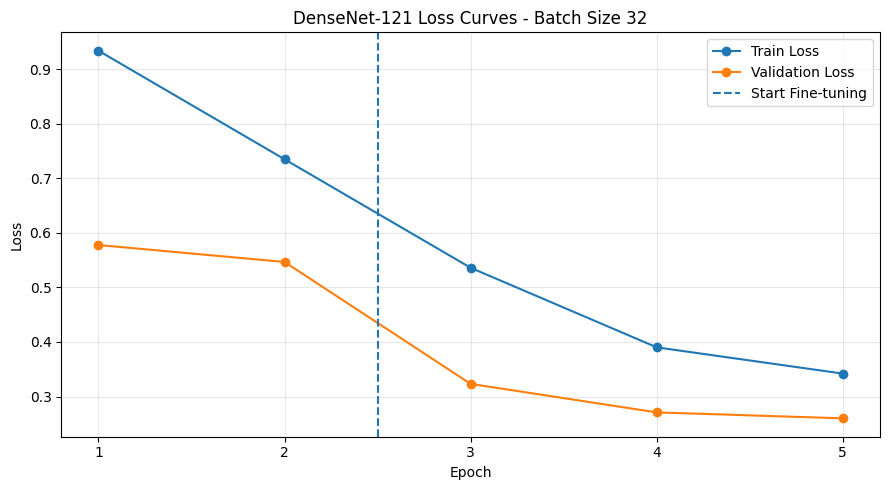

Đã lưu biểu đồ:
C:\Users\LAM LINH\OneDrive\Tài liệu\TQHDL\UTH-Deep-Learning-nhom2\Practice_2\results\figures\densenet121_bs32_loss.png


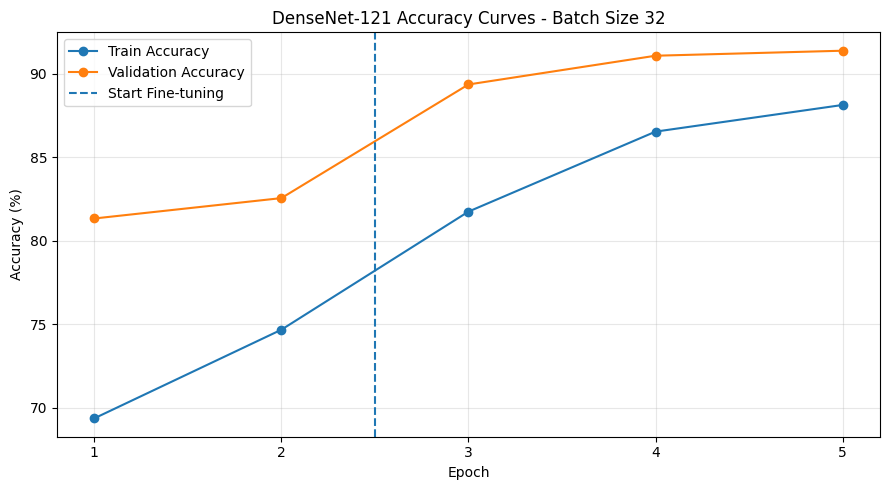

Đã lưu biểu đồ:
C:\Users\LAM LINH\OneDrive\Tài liệu\TQHDL\UTH-Deep-Learning-nhom2\Practice_2\results\figures\densenet121_bs32_accuracy.png


In [38]:
# ============================================================
# LOSS CURVES — BATCH SIZE 32
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    epochs,
    history_32["train_loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    epochs,
    history_32["val_loss"],
    marker="o",
    label="Validation Loss"
)

# Vị trí bắt đầu Fine-tuning
plt.axvline(
    x=TRANSFER_EPOCHS + 0.5,
    linestyle="--",
    label="Start Fine-tuning"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "DenseNet-121 Loss Curves - Batch Size 32"
)

plt.xticks(list(epochs))
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()


loss_figure_bs32 = (
    PROJECT_DIR
    / "results"
    / "figures"
    / "densenet121_bs32_loss.png"
)

plt.savefig(
    loss_figure_bs32,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Đã lưu biểu đồ:")
print(loss_figure_bs32)
# ============================================================
# ACCURACY CURVES — BATCH SIZE 32
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    epochs,
    history_32["train_acc"],
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    epochs,
    history_32["val_acc"],
    marker="o",
    label="Validation Accuracy"
)

plt.axvline(
    x=TRANSFER_EPOCHS + 0.5,
    linestyle="--",
    label="Start Fine-tuning"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title(
    "DenseNet-121 Accuracy Curves - Batch Size 32"
)

plt.xticks(list(epochs))
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()


acc_figure_bs32 = (
    PROJECT_DIR
    / "results"
    / "figures"
    / "densenet121_bs32_accuracy.png"
)

plt.savefig(
    acc_figure_bs32,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Đã lưu biểu đồ:")
print(acc_figure_bs32)

## 5.3. Nhận xét thí nghiệm Batch Size = 32
Kết quả huấn luyện cho thấy DenseNet-121 học ổn định trong cả hai giai đoạn.
### Transfer Learning
Trong 2 epoch đầu, chỉ classifier được huấn luyện:
- Validation Accuracy tăng từ **81.34% lên 82.56%**.
- Validation Loss giảm từ **0.5776 xuống 0.5465**.
Điều này cho thấy các đặc trưng pre-trained của DenseNet-121 có khả năng
chuyển giao tốt sang bài toán CIFAR-10 ngay cả khi backbone được đóng băng.
### Fine-tuning
Sau khi mở `denseblock4`, hiệu năng của mô hình cải thiện rõ rệt:
- Validation Accuracy tăng từ **82.56% lên 89.36%** ngay ở epoch Fine-tuning đầu tiên.
- Best Validation Accuracy đạt **91.38%** ở epoch cuối.
- Validation Loss tiếp tục giảm xuống **0.2601**.

So với Transfer Learning, Fine-tuning cải thiện Best Validation Accuracy
thêm **8.82 điểm phần trăm**.

Train Loss và Validation Loss đều giảm qua các epoch, đồng thời
Train Accuracy và Validation Accuracy đều tăng. Trong phạm vi 5 epoch
thực nghiệm, chưa quan sát thấy dấu hiệu overfitting rõ ràng.

Checkpoint tốt nhất của thí nghiệm Batch Size = 32 được tạo ở giai đoạn
**Fine-tuning**, với Validation Accuracy = **91.38%**.

Thời gian huấn luyện toàn bộ thí nghiệm trên CPU là khoảng
**27,686.89 giây (~7 giờ 41 phút)**.

# 6. Thí nghiệm B — DenseNet-121 với Batch Size = 64
Thí nghiệm thứ hai sử dụng cùng DenseNet-121 và cùng quy trình huấn luyện
với Experiment A, nhưng thay đổi Batch Size từ **32 lên 64**.

Các điều kiện được giữ nguyên:
- Optimizer: Adam
- Learning Rate: 0.001
- Transfer Learning: 2 epochs
- Fine-tuning: 3 epochs
- Random Seed: 42
- Input Size: 224 × 224
- Train/Validation split không thay đổi

Việc giữ cố định các yếu tố trên giúp đánh giá riêng ảnh hưởng của
Batch Size đến Accuracy, Loss và Training Time.

In [41]:
# ============================================================
# EXPERIMENT B — BATCH SIZE = 64
# ============================================================

result_bs64 = run_densenet_experiment(
    batch_size=BATCH_SIZE_B,
    train_loader=train_loader_64,
    val_loader=val_loader_64,
)

DENSENET-121 EXPERIMENT | BATCH SIZE = 64

[STAGE 1] TRANSFER LEARNING
---------------------------------------------
Trainable parameters: 10,250

Epoch [1/2]


Training:  27%|██▋       | 189/704 [14:52<40:31,  4.72s/it]  


KeyboardInterrupt: 